Launch a new python notebook and read the data set. EDA & Pre-processing (Make sure to remove all non-numeric entries from numeric columns) – 5 points

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import preprocessing
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm

In [2]:
# import dataset
df = pd.read_csv("cars-dataset.csv")
df.describe()

,cyl,disp,wt,acc,yr,mpg
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,2970.424623,15.568090,76.010050,23.514573
std,1.701004,104.269838,846.841774,2.757689,3.697627,7.815984
min,3.000000,68.000000,1613.000000,8.000000,70.000000,9.000000
25%,4.000000,104.250000,2223.750000,13.825000,73.000000,17.500000
50%,4.000000,148.500000,2803.500000,15.500000,76.000000,23.000000
75%,8.000000,262.000000,3608.000000,17.175000,79.000000,29.000000
max,8.000000,455.000000,5140.000000,24.800000,82.000000,46.600000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [4]:
# scrutinizing variable 'hp' as the same is object type (needs to be numerical)
df[pd.to_numeric(df['hp'], errors='coerce').isnull()]

,car name,cyl,disp,hp,wt,acc,yr,mpg
32,ford pinto,4,98.0,?,2046,19.0,71,25.0
126,ford maverick,6,200.0,?,2875,17.0,74,21.0
330,renault lecar deluxe,4,85.0,?,1835,17.3,80,40.9
336,ford mustang cobra,4,140.0,?,2905,14.3,80,23.6
354,renault 18i,4,100.0,?,2320,15.8,81,34.5
374,amc concord dl,4,151.0,?,3035,20.5,82,23.0


In [5]:
# replacing '?' with nan for missing values treatment
df = df.replace('?', np.nan)

In [6]:
df = df.apply(pd.to_numeric, errors = 'coerce')

In [7]:
# treating missing values with mean
df = df.fillna(df.mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    0 non-null float64
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null float64
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [8]:
# Applying standard scalar
df_for_scaling = df.drop('car name', axis=1)
scaler = preprocessing.StandardScaler()
scaled_df = scaler.fit_transform(df_for_scaling)
scaled_df = pd.DataFrame(scaled_df)
scaled_df.columns = ['cyl','disp','hp','wt','acc','yr','mpg']

In [9]:
scaled_df.head()

,cyl,disp,hp,wt,acc,yr,mpg
0,1.498191,1.090604,0.669196,0.630870,-1.295498,-1.627426,-0.706439
1,1.498191,1.503514,1.586599,0.854333,-1.477038,-1.627426,-1.090751
2,1.498191,1.196232,1.193426,0.550470,-1.658577,-1.627426,-0.706439
3,1.498191,1.061796,1.193426,0.546923,-1.295498,-1.627426,-0.962647
4,1.498191,1.042591,0.931311,0.565841,-1.840117,-1.627426,-0.834543


Use pair plot or scatter matrix to visualize how the different variables are related (Hint: The amount of Gaussian curves in the plot should give a visual identification of different clusters existing in the dataset) – 5 points

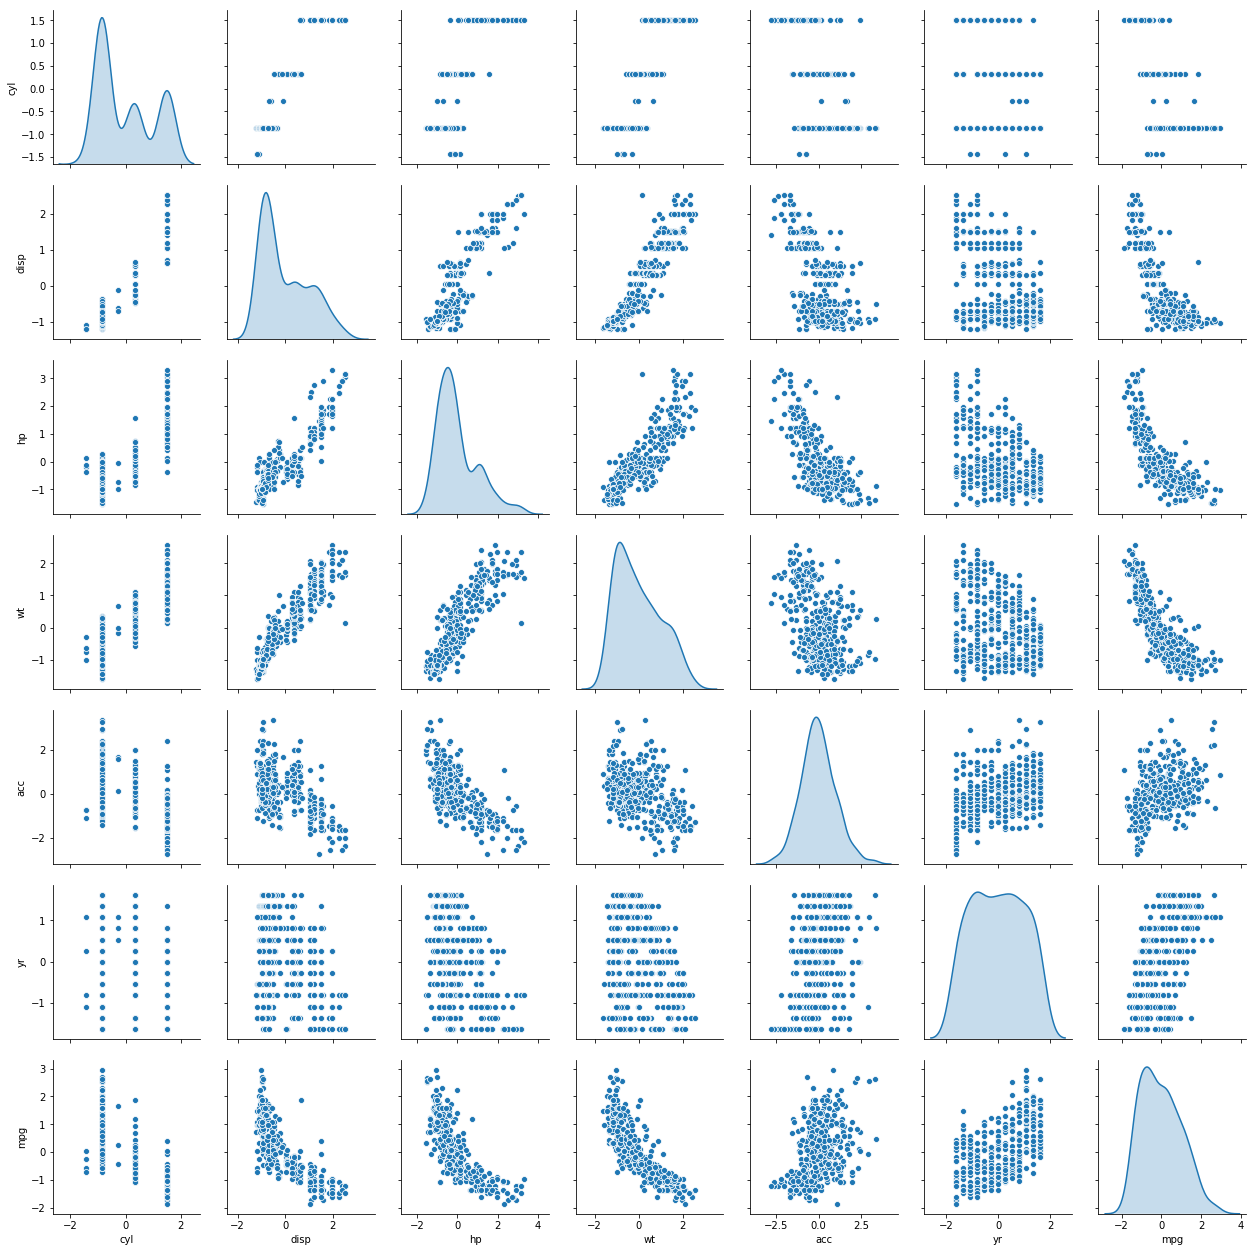

In [10]:
# plotting pairplot to check on gaussian curves for each variable as well as other relations
sns.pairplot(scaled_df, diag_kind='kde') 

Use K Means or Hierarchical clustering to find out the optimal number of clusters in the data. Identify and separate the clusters (10 points)

K Means clustering

In [11]:
# expect 3 to 4 clusters from the pair panel visual inspection hence restricting from 2 to 10
cluster_range = range(2, 10)   
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(scaled_df)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
clusters_df[0:15]

,num_clusters,cluster_errors
0,2,1296.233079
1,3,947.599831
2,4,740.051470
3,5,666.591466
4,6,596.555707
5,7,544.213442
6,8,500.214588
7,9,469.261624


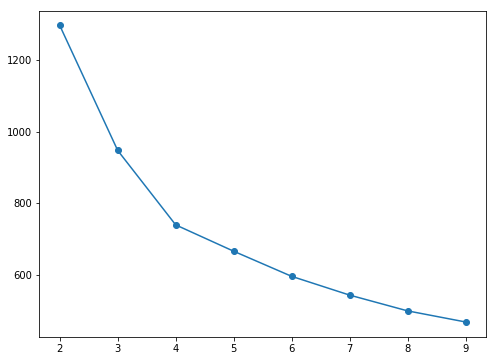

In [12]:
# Elbow plot
plt.figure(figsize=(8,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [13]:
# fitting 4 clusters as per elbow plot
cluster = KMeans( n_clusters = 4, random_state = 2354 )
cluster.fit(scaled_df)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=4, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=2354, tol=0.0001, verbose=0)

In [14]:
# Calculating centroid values
centroids = cluster.cluster_centers_
centroid_df = pd.DataFrame(centroids, columns = list(scaled_df))

In [15]:
centroid_df

,cyl,disp,hp,wt,acc,yr,mpg
0,1.498191,1.503923,1.518282,1.404098,-1.086149,-0.688324,-1.163797
1,-0.825340,-0.781645,-0.735218,-0.768570,0.374983,1.101793,1.180173
2,-0.862266,-0.808523,-0.559179,-0.758636,0.329555,-0.645492,0.202711
3,0.424430,0.305303,-0.038956,0.337765,0.293670,0.032986,-0.496827


In [16]:
# Creating a new column "GROUP" which will hold the cluster id of each record
prediction=cluster.predict(scaled_df)
scaled_df["GROUP_kmeans"] = prediction 

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001F10DFF46A0>,
      dtype=object)

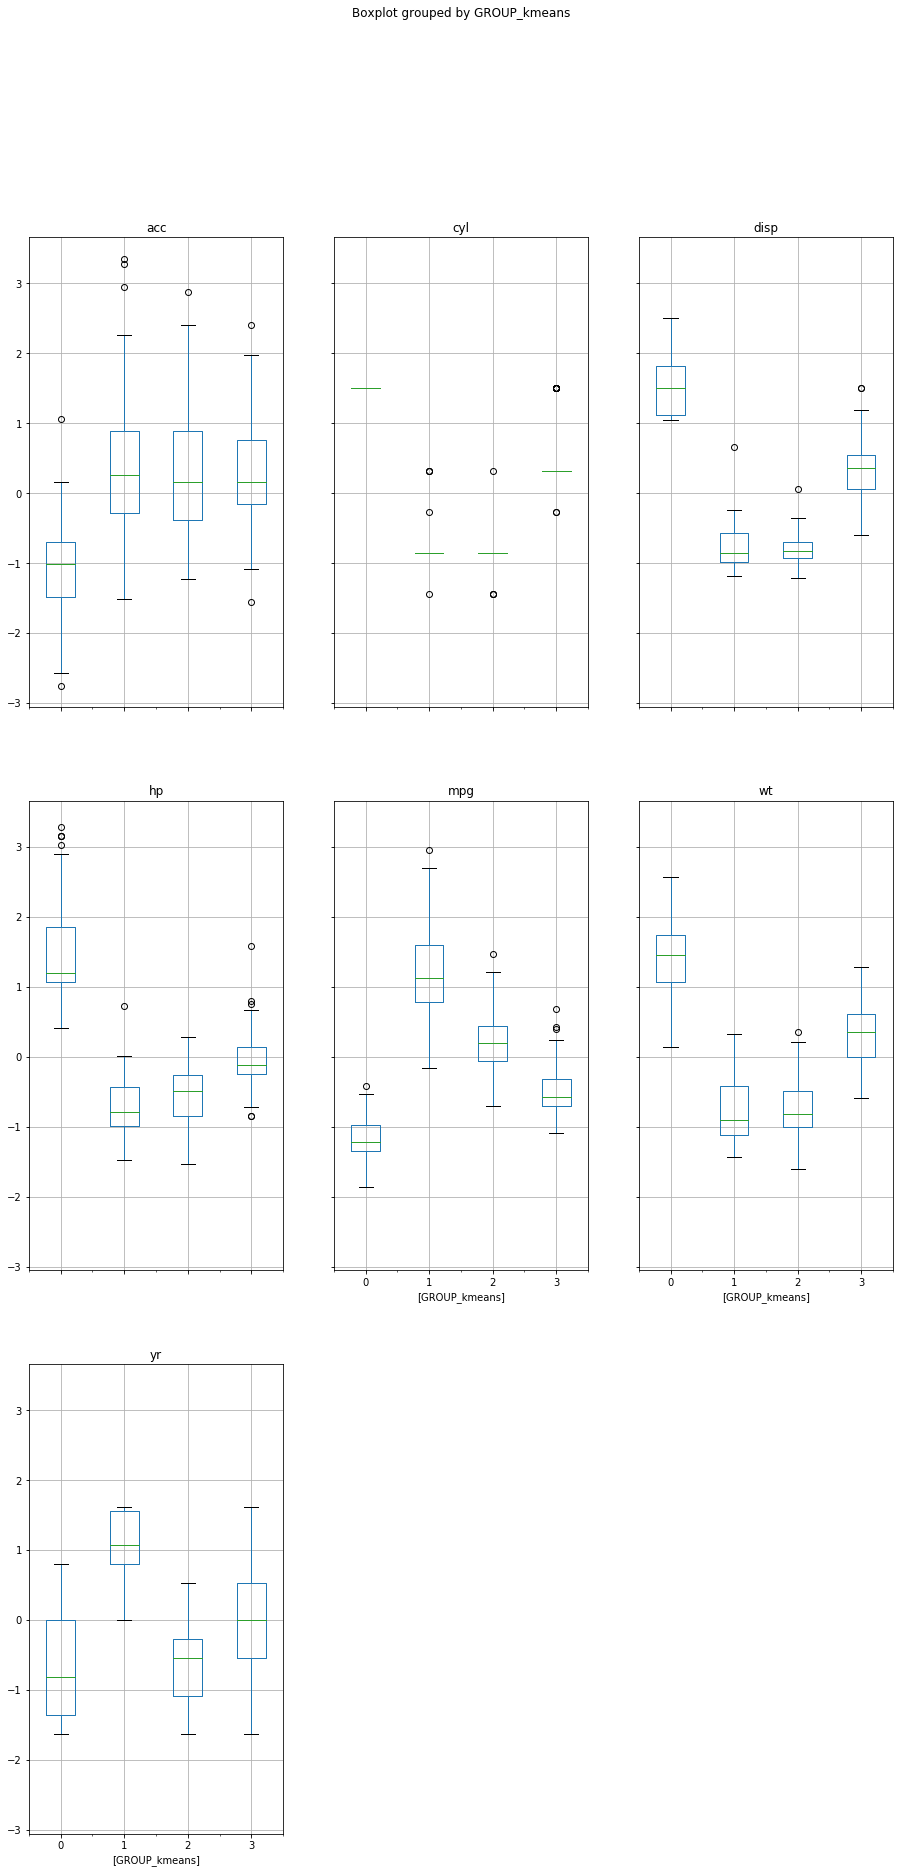

In [17]:
# visualizing box plots to evaluate identified clusters
scaled_df.boxplot(by = 'GROUP_kmeans',  layout=(4,3), figsize=(15, 40))

Hierarchical clustering

In [18]:
# Calculate the linkage_matrix
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import linkage, dendrogram
linkage_matrix = linkage(scaled_df,method='ward')

In [19]:
# Check on cophenet value
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist
c, coph_dists = cophenet(linkage_matrix, pdist(scaled_df))
c

0.8577049581618714

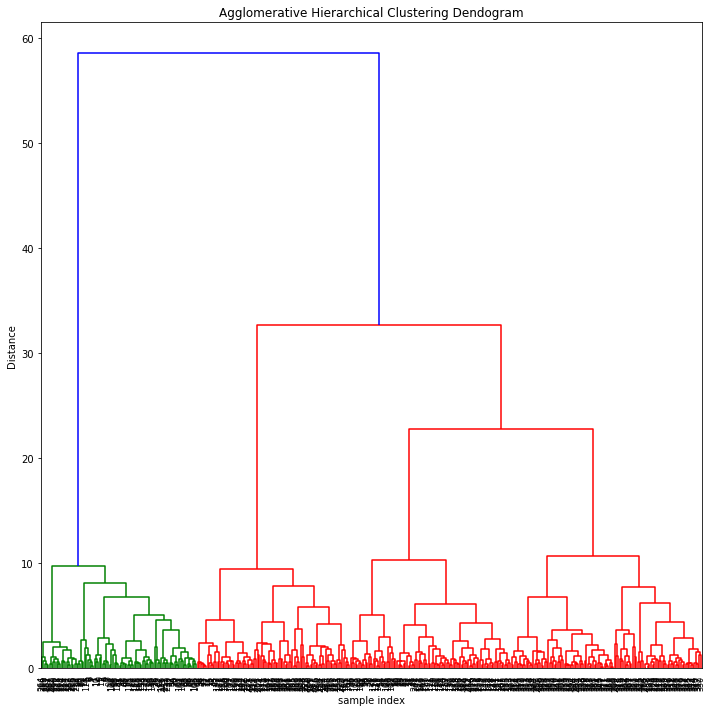

In [20]:
# Plot the dendrogram for the consolidated dataframe
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(linkage_matrix, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

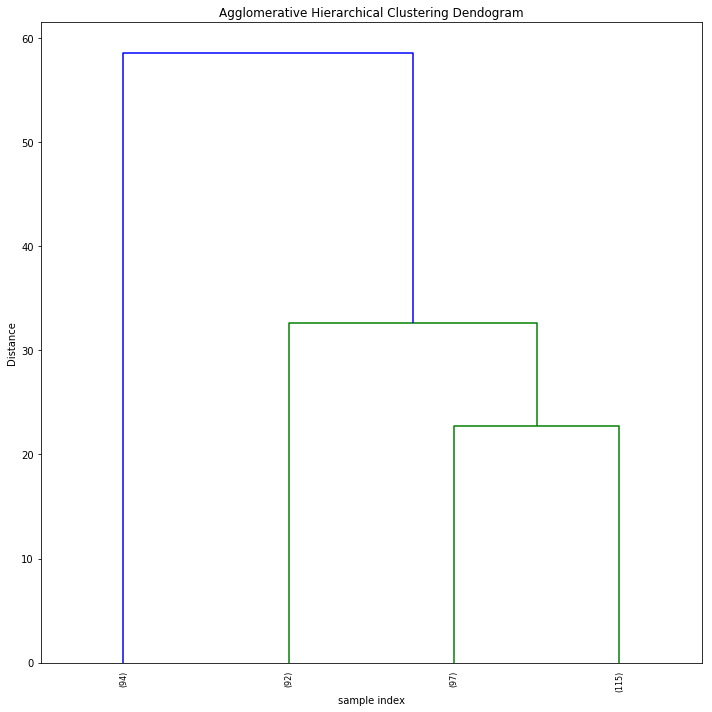

In [21]:
# Recreate the dendrogram for last 4 merged clusters
plt.figure(figsize=(10, 10))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(linkage_matrix, truncate_mode='lastp', p=4, leaf_rotation=90.,color_threshold = 40, leaf_font_size=8. )
plt.tight_layout()

In [22]:
# scipy.cluster.hierarchy.fcluster can be used to flatten the dendrogram, obtaining as a result an assignation of the original data points to single clusters.
# This assignation mostly depends on a distance threshold t - the maximum inter-cluster distance allowed
from scipy.cluster.hierarchy import fcluster
clusters = fcluster(linkage_matrix, t=11, criterion='distance')

In [23]:
# attached results as new column to dataframe
scaled_df = scaled_df.join(pd.DataFrame(clusters))
scaled_df = scaled_df.rename(columns={ scaled_df.columns[-1]: "GROUP_hierarchy" })

In [24]:
# Converting clusters as string labels
scaled_df['GROUP_kmeans'] = scaled_df['GROUP_kmeans'].apply(str)
scaled_df['GROUP_hierarchy'] = scaled_df['GROUP_hierarchy'].apply(str)
scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
cyl                398 non-null float64
disp               398 non-null float64
hp                 398 non-null float64
wt                 398 non-null float64
acc                398 non-null float64
yr                 398 non-null float64
mpg                398 non-null float64
GROUP_kmeans       398 non-null object
GROUP_hierarchy    398 non-null object
dtypes: float64(7), object(2)
memory usage: 28.1+ KB


In [25]:
# Generating cross-tab results to evaluate labels generated by two clustering techniques
pd.crosstab(scaled_df.GROUP_kmeans, scaled_df.GROUP_hierarchy,margins=True)

GROUP_hierarchy,1,2,3,4,All
GROUP_kmeans,,,,,
0,94,0,0,0,94
1,0,0,0,114,114
2,0,1,97,1,99
3,0,91,0,0,91
All,94,92,97,115,398


Use linear regression model on different clusters separately and print the coefficients of the models individually (10 points)

In [26]:
# Given that most of the labels match from both the techniques, using one of the cluster labels (GROUP_kmeans)
# to divide dataframe into 4 groups for linear regression
df1 = scaled_df.loc[scaled_df["GROUP_kmeans"] == '0']
df2 = scaled_df.loc[scaled_df["GROUP_kmeans"] == '1']
df3 = scaled_df.loc[scaled_df["GROUP_kmeans"] == '2']
df4 = scaled_df.loc[scaled_df["GROUP_kmeans"] == '3']

In [27]:
## Multiple Linear Regression for group1
m_linear_mod_1 = sm.ols(formula ="mpg ~ cyl + disp + hp+ wt + acc + yr" ,data = df1).fit()
#m_linear_mod_1.summary()

In [28]:
## Multiple Linear Regression for group2
m_linear_mod_2 = sm.ols(formula ="mpg ~ cyl + disp + hp+ wt + acc + yr" ,data = df2).fit()
#m_linear_mod_2.summary()

In [29]:
## Multiple Linear Regression for group3
import statsmodels.formula.api as sm
m_linear_mod_3 = sm.ols(formula ="mpg ~ cyl + disp + hp+ wt + acc + yr" ,data = df3).fit()
#m_linear_mod_3.summary()

In [30]:
## Multiple Linear Regression for group4
import statsmodels.formula.api as sm
m_linear_mod_4 = sm.ols(formula ="mpg ~ cyl + disp + hp+ wt + acc + yr" ,data = df4).fit()
#m_linear_mod_4.summary()

In [31]:
# print the coefficients of the models individually 
print("coefficients of the cluster 1:")
print(m_linear_mod_1.params)
print("coefficients of the cluster 2:")
print(m_linear_mod_2.params)
print("coefficients of the cluster 3:")
print(m_linear_mod_3.params)
print("coefficients of the cluster 4:")
print(m_linear_mod_4.params)

coefficients of the cluster 1:
Intercept   -0.251578
cyl         -0.376912
disp        -0.075263
hp          -0.092974
wt          -0.119222
acc         -0.183226
yr           0.181301
dtype: float64
coefficients of the cluster 2:
Intercept    0.595212
cyl          1.067477
disp        -0.173728
hp          -0.254127
wt          -0.940179
acc          0.119879
yr           0.341095
dtype: float64
coefficients of the cluster 3:
Intercept    0.002156
cyl          0.848792
disp        -0.659220
hp          -0.191240
wt          -0.546660
acc         -0.079518
yr           0.148727
dtype: float64
coefficients of the cluster 4:
Intercept   -0.428736
cyl          0.183881
disp        -0.017062
hp          -0.137705
wt          -0.405518
acc         -0.057424
yr           0.228673
dtype: float64
